# Campaign Specification Formats

A `Campaign` schedule can be loaded from any of five sources, all equivalent:

1. A single Python **`dict`** (one entry)
2. A Python **`list`** of entry dicts
3. A **`.json`** file on disk
4. A **`.yaml`** / **`.yml`** file on disk
5. A **`.csv`** file on disk

This notebook walks through three of them — inline (list of dicts), JSON file, and CSV file — using **Scenario A from `nb_17_campaign_example.ipynb`** (a 6-node hub-and-spoke SIR with biannual 50% vaccination and monthly importation into the hub).  We verify that all three on-disk forms produce *identical* results.

The YAML loader follows the same shape as the JSON loader (a top-level list of entry mappings, or a single mapping for a one-entry schedule) — see `tests/data/campaign_sample.yaml` for an annotated reference file and `docs/campaign.md` for the full grammar.

The final section shows a more elaborate **cycling vaccination** schedule that visits each population center on a rotating 60-day cadence — a useful template for outreach campaigns that can only visit one location at a time.  The cycling schedule is defined inline and then dumped to JSON to show what that JSON form looks like.

In [50]:
import csv
import json
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from laser.core import PropertySet
from laser.core.utils import grid
from laser.generic.utils import ValuesMap
from laser.cohorts import Model, Campaign, Intervention
from laser.cohorts.vitaldynamics import NonDiseaseMortality, ConstantPopBirths
import laser.cohorts.SIR as SIR

tmpdir = Path(tempfile.mkdtemp(prefix="campaign_specs_"))
print(f"Working directory for JSON/CSV examples: {tmpdir}")

Working directory for JSON/CSV examples: /var/folders/fl/_ns4br_j2qxd92vjrgl3t4n00000gn/T/campaign_specs_gymukxdg


## Intervention classes

Both examples use the same two interventions as `nb_17_campaign_example.ipynb`:

- `Importation` — adds a fixed `count` of infectious individuals to targeted nodes when it fires.
- `Vaccination` — converts a binomial-drawn fraction of susceptibles into a new `V` (vaccinated) compartment, recording doses delivered on a `new_vaccinations` node property.

Both must be registered with `Campaign.register` **before** the schedule is loaded — the registry is checked at validation time.

In [51]:
class Importation(Intervention):
    """Inject `count` infectious individuals into the targeted nodes."""

    @property
    def states(self):
        return ["S", "I", "R"]

    @property
    def properties(self):
        return []

    def apply(self, tick, who, where, params, notes):
        count  = int(params.get("count", 1))
        target = where if where is not None else list(range(len(self.model.scenario)))
        for node in target:
            self.model.states.I[tick + 1][node] += count


class Vaccination(Intervention):
    """Move a binomial-drawn fraction of susceptibles into a V compartment."""

    @property
    def states(self):
        return ["S", "V"]

    @property
    def properties(self):
        return [("new_vaccinations", self.model.params.nticks, np.int32, 0)]

    def apply(self, tick, who, where, params, notes):
        coverage = float(params.get("coverage", 0.0))
        target   = where if where is not None else list(range(len(self.model.scenario)))
        for node in target:
            S_count = int(self.model.states.S[tick + 1][node])
            doses   = int(np.random.binomial(S_count, coverage))
            self.model.states.S[tick + 1][node]           -= doses
            self.model.states.V[tick + 1][node]           += doses
            self.model.nodes.new_vaccinations[tick][node] += doses


Campaign.register(Importation)
Campaign.register(Vaccination)
print("Registered: Importation, Vaccination")

Registered: Importation, Vaccination


## Scenario A parameters and `build_and_run` helper

In [52]:
# Disease parameters (measles-like)
R0                    = 10.0
infectious_period     = 7.0
gamma_val             = 1.0 / infectious_period
beta_val              = R0 / infectious_period
life_expectancy_years = 60.0
r_mortality_val       = 1.0 / (life_expectancy_years * 365.0)

# Network coupling
hub_coupling  = 0.05
ring_coupling = 0.01

# Simulation length: 10 years
nticks  = 10 * 365
n_nodes = 6

# Populations: hub + 5 spokes
populations = np.array([500_000] + [50_000] * (n_nodes - 1), dtype=np.int64)

# Schedule cadences shared across the three examples
import_period = 30
vacc_period   = 182
when_imports  = list(range(0, nticks, import_period))
when_vacc     = list(range(0, nticks, vacc_period))

print(f"populations    = {populations.tolist()}")
print(f"import events  = {len(when_imports)} (every {import_period} days)")
print(f"vacc events    = {len(when_vacc)} (every {vacc_period} days)")

populations    = [500000, 50000, 50000, 50000, 50000, 50000]
import events  = 122 (every 30 days)
vacc events    = 21 (every 182 days)


In [53]:
def build_and_run(populations, source, *, hub_seed=10, seed=42):
    """Build the hub-and-spoke SIR model with the given Campaign source and run it.

    `source` can be any value accepted by `Campaign`: a dict, a list of dicts,
    or a path to a .json / .yaml / .yml / .csv file.  Reseeds `np.random`
    before constructing the model so every run with the same `seed` is
    bit-for-bit reproducible.
    """
    np.random.seed(seed)

    n = len(populations)
    n_sp = n - 1

    # Hub-spoke + ring network
    net = np.zeros((n, n), dtype=np.float32)
    for k in range(1, n):
        net[0, k] = hub_coupling
        net[k, 0] = hub_coupling
    for k in range(1, n):
        nbr = (k % n_sp) + 1
        net[k, nbr] = ring_coupling
        net[nbr, k] = ring_coupling

    # Endemic equilibrium initial conditions
    S_frac = 1.0 / R0
    I_init = np.zeros(n, dtype=np.int32)
    I_init[0] = hub_seed
    S_init = (populations * S_frac).astype(np.int32)
    R_init = populations.astype(np.int32) - S_init - I_init

    scen = grid(M=n, N=1)
    scen["S"] = S_init
    scen["I"] = I_init
    scen["R"] = R_init

    p = PropertySet({"nticks": nticks})
    m = Model(scen, p)
    m.network = net

    camp           = Campaign(m, source)
    betas_         = ValuesMap.from_scalar(beta_val,  nticks, n)
    r_recoveries_  = ValuesMap.from_scalar(gamma_val, nticks, n)

    m.components = [
        SIR.Susceptible(m),
        SIR.Infectious(m, r_recovery=r_recoveries_),
        SIR.Recovered(m),
        NonDiseaseMortality(m, r_mortality=r_mortality_val),
        ConstantPopBirths(m),
        camp,
        SIR.Transmission(m, beta=betas_),
    ]
    m.run()
    return m

---

## Example 1 — Inline specification (list of dicts)

The most direct form: build the schedule as a Python list of dicts and hand it straight to `Campaign`.  Useful for prototyping or for cases where the schedule is generated programmatically (e.g. by sweeping a parameter).

In [54]:
schedule_inline = [
    {
        "who": "*",
        "what": "Importation",
        "when": when_imports,
        "where": [0],
        "parameters": {"count": 2},
        "notes": "monthly external importation into the hub",
    },
    {
        "who": ["S"],
        "what": "Vaccination",
        "when": when_vacc,
        "where": "*",
        "parameters": {"coverage": 0.5},
        "notes": "biannual 50% S\u2192V campaign",
    },
]

print(f"Inline schedule: {len(schedule_inline)} entries")
for entry in schedule_inline:
    print(f"  - {entry['what']:<14s} fires {len(entry['when']):>3d}x at {entry['where']}")

model_inline = build_and_run(populations, schedule_inline)
print(f"\nTotal doses : {model_inline.nodes.new_vaccinations.sum():>10,}")
print(f"Total cases : {model_inline.nodes.newly_infectious.sum():>10,}")

Inline schedule: 2 entries
  - Importation    fires 122x at [0]
  - Vaccination    fires  21x at *

Total doses :    191,759
Total cases :         56


---

## Example 2 — JSON file

The JSON form mirrors the inline form one-for-one: a JSON array of entry objects.  This is the natural format for sharing or version-controlling a campaign definition alongside the model code.

In [55]:
json_path = tmpdir / "scenario_a.json"
json_path.write_text(json.dumps(schedule_inline, indent=2))

# Show what the JSON file actually looks like
json_text = json_path.read_text()
preview_lines = json_text.splitlines()
if len(preview_lines) > 24:
    preview = "\n".join(preview_lines[:12] + ["        ... (truncated for display) ..."] + preview_lines[-6:])
else:
    preview = json_text
print(f"--- {json_path.name} ---")
print(preview)
print(f"--- end ({len(json_text):,} bytes, {len(preview_lines)} lines) ---")

--- scenario_a.json ---
[
  {
    "who": "*",
    "what": "Importation",
    "when": [
      0,
      30,
      60,
      90,
      120,
      150,
      180,
        ... (truncated for display) ...
    "parameters": {
      "coverage": 0.5
    },
    "notes": "biannual 50% S\u2192V campaign"
  }
]
--- end (2,073 bytes, 171 lines) ---


In [56]:
# Load directly from the JSON path -- Campaign auto-dispatches on the suffix
model_json = build_and_run(populations, json_path)
print(f"Total doses : {model_json.nodes.new_vaccinations.sum():>10,}")
print(f"Total cases : {model_json.nodes.newly_infectious.sum():>10,}")

Total doses :    191,759
Total cases :         56


---

## Example 3 — CSV file

CSV is one row per schedule entry.  Three of the six columns naturally hold lists (`who`, `where`, `when`) or a dict (`parameters`); for CSV cells we write those values as **JSON-encoded strings**.  The Campaign loader recognises the bracket and parses each cell back into the right shape.

In [57]:
def _cell(value):
    """Encode a schedule field for a CSV cell.

    Lists and dicts become JSON-encoded strings; ``"*"`` stays literal; ints
    and bare strings pass through unchanged.
    """
    if isinstance(value, (list, dict)):
        return json.dumps(value)
    return value

csv_path = tmpdir / "scenario_a.csv"
with csv_path.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["who", "what", "when", "where", "parameters", "notes"])
    writer.writeheader()
    for entry in schedule_inline:
        writer.writerow({
            "who":        _cell(entry["who"]),
            "what":       entry["what"],
            "when":       _cell(entry["when"]),
            "where":      _cell(entry["where"]),
            "parameters": _cell(entry["parameters"]),
            "notes":      entry["notes"],
        })

csv_text = csv_path.read_text()
# Truncate wide cells for display readability
lines = csv_text.splitlines()
shown = []
for line in lines:
    shown.append(line if len(line) <= 140 else line[:137] + "...")
print(f"--- {csv_path.name} ({len(csv_text):,} bytes) ---")
for line in shown:
    print(line)
print("--- end ---")

--- scenario_a.csv (1,003 bytes) ---
who,what,when,where,parameters,notes
*,Importation,"[0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570, 600, 630, 660, 690, 720, 7...
"[""S""]",Vaccination,"[0, 182, 364, 546, 728, 910, 1092, 1274, 1456, 1638, 1820, 2002, 2184, 2366, 2548, 2730, 2912, 3094, 3276, 3458, 3...
--- end ---


In [58]:
model_csv = build_and_run(populations, csv_path)
print(f"Total doses : {model_csv.nodes.new_vaccinations.sum():>10,}")
print(f"Total cases : {model_csv.nodes.newly_infectious.sum():>10,}")

Total doses :    191,759
Total cases :         56


## Equivalence check

All three runs use `np.random.seed(42)` and the same schedule content, so their compartment trajectories must be **bit-for-bit identical**.  An exact-equality check is the right assertion here — any drift between the three formats would indicate a real bug in the loader.

inline == JSON: bit-for-bit identical
inline == CSV : bit-for-bit identical


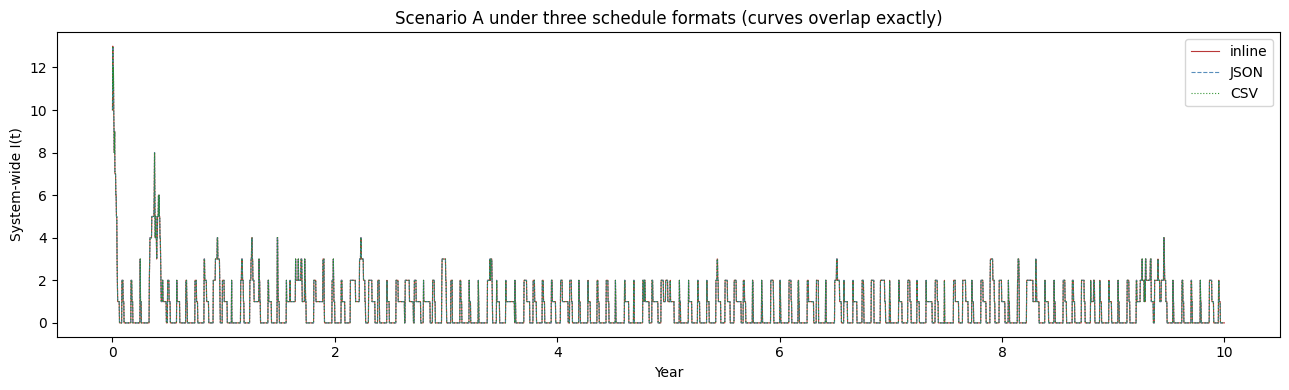

In [59]:
I_inline = model_inline.states.I.sum(axis=1)
I_json   = model_json.states.I.sum(axis=1)
I_csv    = model_csv.states.I.sum(axis=1)

assert np.array_equal(I_inline, I_json), "inline vs JSON diverge"
assert np.array_equal(I_inline, I_csv),  "inline vs CSV  diverge"

print("inline == JSON: bit-for-bit identical")
print("inline == CSV : bit-for-bit identical")

t_years = np.arange(nticks + 1) / 365.0
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(t_years, I_inline, color="firebrick",   linewidth=0.8, alpha=0.9,                  label="inline")
ax.plot(t_years, I_json,   color="steelblue",   linewidth=0.8, alpha=0.9, linestyle="--",  label="JSON")
ax.plot(t_years, I_csv,    color="forestgreen", linewidth=0.8, alpha=0.9, linestyle=":",   label="CSV")
ax.set_xlabel("Year")
ax.set_ylabel("System-wide I(t)")
ax.set_title("Scenario A under three schedule formats (curves overlap exactly)")
ax.legend()
plt.tight_layout()
plt.show()

---

## Example 4 — Cycling vaccination across population centers

Real outreach campaigns often visit one location at a time.  The next example replaces the every-tick, every-node vaccination with a **cycling** schedule:

- Every 60 days a vaccination round fires in exactly **one** node.
- The visit rotates through the six population centers in order: hub → spoke 1 → spoke 2 → … → spoke 5 → hub → ...
- Each individual node therefore receives a vaccination round every $6 \times 60 = 360$ days (≈ once per year).
- Coverage at each visit is the same 50% as Scenario A.
- Hub importation continues as before.

Each node ends up with its own list of firing ticks, so the natural representation is one schedule entry per node (plus the importation entry).

In [60]:
visit_period = 60          # days between visits
cycle_period = visit_period * n_nodes   # 360 days to revisit a node

schedule_cycle = [
    {
        "who": "*",
        "what": "Importation",
        "when": when_imports,
        "where": [0],
        "parameters": {"count": 2},
        "notes": "monthly external importation into the hub",
    },
]

for node in range(n_nodes):
    node_ticks = list(range(node * visit_period, nticks, cycle_period))
    label      = "hub" if node == 0 else f"spoke {node}"
    schedule_cycle.append({
        "who":        ["S"],
        "what":       "Vaccination",
        "when":       node_ticks,
        "where":      [node],
        "parameters": {"coverage": 0.5},
        "notes":      f"cycling visit to {label}",
    })

print(f"Cycling schedule: {len(schedule_cycle)} entries")
for entry in schedule_cycle:
    visits = len(entry["when"])
    first  = entry["when"][0] if visits else "-"
    print(f"  - {entry['what']:<14s} where={str(entry['where']):<6s}  {visits:>2d} firings (first @ tick {first})")

Cycling schedule: 7 entries
  - Importation    where=[0]     122 firings (first @ tick 0)
  - Vaccination    where=[0]     11 firings (first @ tick 0)
  - Vaccination    where=[1]     10 firings (first @ tick 60)
  - Vaccination    where=[2]     10 firings (first @ tick 120)
  - Vaccination    where=[3]     10 firings (first @ tick 180)
  - Vaccination    where=[4]     10 firings (first @ tick 240)
  - Vaccination    where=[5]     10 firings (first @ tick 300)


In [61]:
model_cycle = build_and_run(populations, schedule_cycle)

print(f"Total doses : {model_cycle.nodes.new_vaccinations.sum():>10,}")
print(f"Total cases : {model_cycle.nodes.newly_infectious.sum():>10,}")
print("Per-node doses delivered:")
for i in range(n_nodes):
    label  = "hub" if i == 0 else f"spoke {i}"
    doses  = int(model_cycle.nodes.new_vaccinations[:, i].sum())
    visits = int((model_cycle.nodes.new_vaccinations[:, i] > 0).sum())
    print(f"  node {i} ({label:<7s})  {doses:>8,} doses across {visits} visits")

Total doses :    179,762
Total cases :         83
Per-node doses delivered:
  node 0 (hub    )   121,337 doses across 11 visits
  node 1 (spoke 1)    11,470 doses across 10 visits
  node 2 (spoke 2)    11,534 doses across 10 visits
  node 3 (spoke 3)    11,720 doses across 10 visits
  node 4 (spoke 4)    11,828 doses across 10 visits
  node 5 (spoke 5)    11,873 doses across 10 visits


### Visualising the cycling pattern

We plot each vaccination event as a circle at *(time, node)*, sized by the number of doses delivered.  Square-root area scaling is used so that the hub's ~10× larger doses don't drown out the spoke visits — instead the hub circles end up roughly 3× the radius of the spoke circles, leaving every visit individually readable.  The diagonal staircase 0 → spoke 1 → spoke 2 → ... → spoke 5 → 0 → ... is exactly the cycling pattern we configured.

The bottom panel shows the corresponding per-node infectious dynamics so the cycling visits can be lined up against the local epidemic waves.

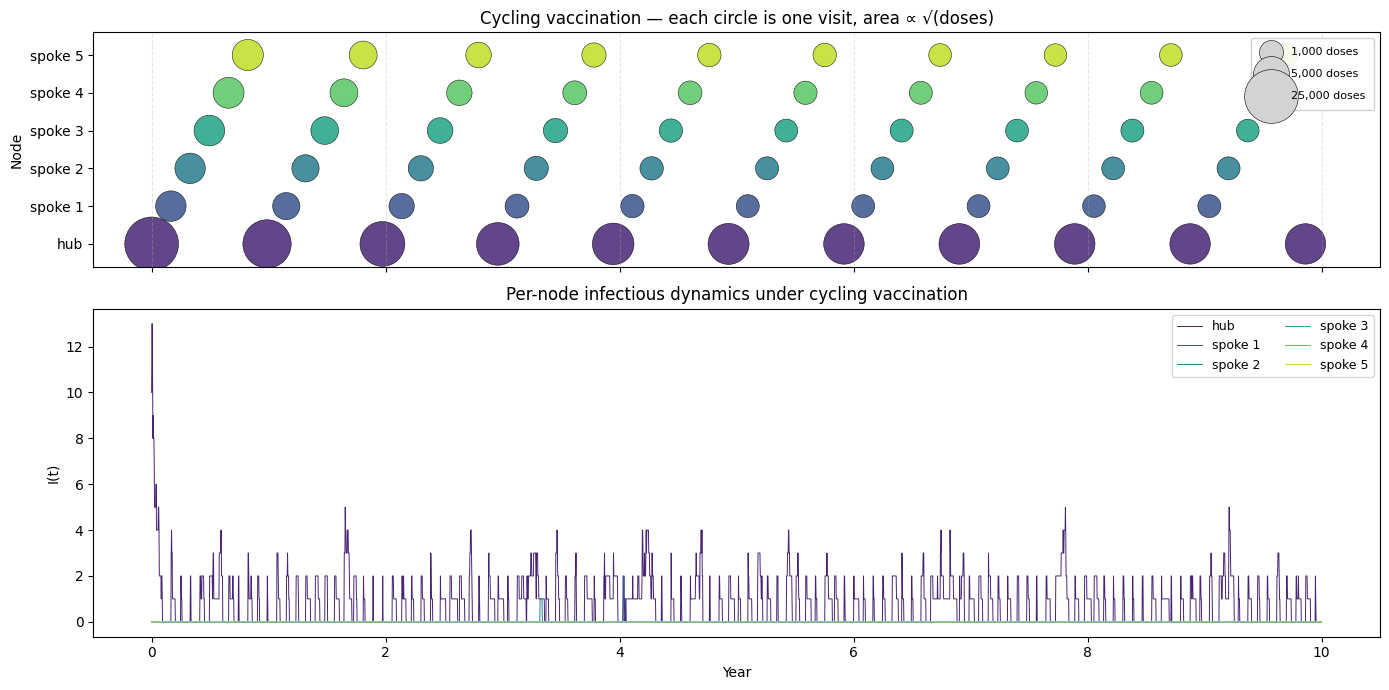

Visits ranged from 767 to 25,085 doses.


In [62]:
nv = model_cycle.nodes.new_vaccinations           # (nticks, n_nodes)

# Extract every (tick, node) pair where doses > 0
event_ticks, event_nodes = np.nonzero(nv)
event_doses              = nv[event_ticks, event_nodes]
event_years              = event_ticks / 365.0

# Per-node color so circles on the same row read as one rotation
node_colors = plt.cm.viridis(np.linspace(0.1, 0.9, n_nodes))
event_colors = [node_colors[n] for n in event_nodes]

# Square-root area scaling — keeps hub and spoke visits both readable.
# Matplotlib `s` is area in points^2; we want radius ∝ √doses, so area ∝ doses.
# To avoid hub circles >10× bigger than spokes (linear-area), scale on √doses instead.
max_dose = event_doses.max()
sizes    = (event_doses / max_dose) ** 0.5 * 1500.0

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                          gridspec_kw={"height_ratios": [1, 1.4]})

axes[0].scatter(event_years, event_nodes, s=sizes, c=event_colors,
                 edgecolors="black", linewidth=0.4, alpha=0.85)
axes[0].set_yticks(range(n_nodes))
axes[0].set_yticklabels(["hub"] + [f"spoke {i}" for i in range(1, n_nodes)])
axes[0].set_ylabel("Node")
axes[0].set_ylim(-0.6, n_nodes - 0.4)
axes[0].set_title("Cycling vaccination — each circle is one visit, area ∝ √(doses)")
axes[0].grid(True, axis="x", alpha=0.3, linestyle="--")

# Size legend: a few reference dose counts
ref_doses = [1_000, 5_000, 25_000, 100_000]
for d in ref_doses:
    if d <= max_dose * 1.2:
        s = (d / max_dose) ** 0.5 * 1500.0
        axes[0].scatter([], [], s=s, c="lightgray", edgecolors="black",
                         linewidth=0.4, label=f"{d:,} doses")
axes[0].legend(loc="upper right", scatterpoints=1, fontsize=8, framealpha=0.9,
                labelspacing=1.1, borderpad=0.8)

# Bottom: per-node infectious dynamics under cycling
t_years_full = np.arange(nticks + 1) / 365.0
for i in range(n_nodes):
    label = "hub" if i == 0 else f"spoke {i}"
    axes[1].plot(t_years_full, model_cycle.states.I[:, i], linewidth=0.7,
                  color=node_colors[i], label=label)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("I(t)")
axes[1].set_title("Per-node infectious dynamics under cycling vaccination")
axes[1].legend(loc="upper right", ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

print(f"Visits ranged from {event_doses.min():,} to {event_doses.max():,} doses.")

### Per-node susceptible fraction under cycling vaccination

The infectious dynamics are easier to interpret once you see the underlying **susceptible** pool that drives them.  Each cycling visit takes a sharp 50% bite out of $S(t)$ in the visited node; between visits, the susceptible cohort rebuilds at the per-capita birth rate.

The dashed horizontal line marks the endemic equilibrium $S^* / N = 1/R_0$.  Without vaccination, every node would oscillate around it.  With cycling vaccination, $S/N$ is held meaningfully below the equilibrium most of the time — this is the proximate cause of the suppressed transmission visible in the top-row $I(t)$ panel.

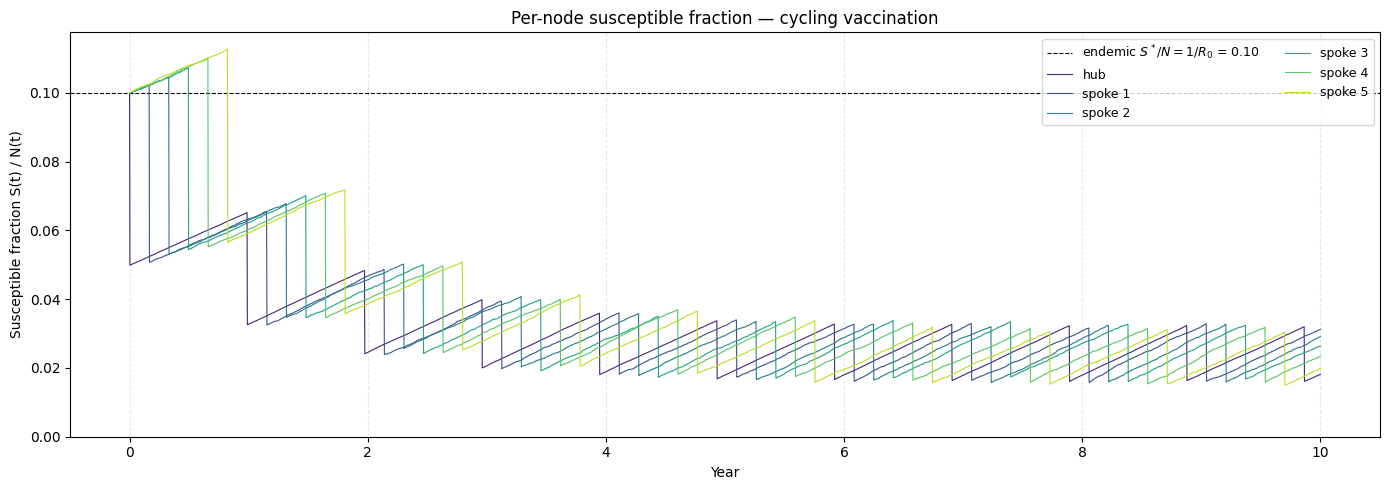

In [63]:
# Per-node total population — needed to convert S to a fraction
N_per_node_cycle = (model_cycle.states.S + model_cycle.states.I
                    + model_cycle.states.R + model_cycle.states.V)

fig, ax = plt.subplots(figsize=(14, 5))
ax.axhline(1.0 / R0, color="black", linestyle="--", linewidth=0.8,
           label=fr"endemic $S^*/N = 1/R_0$ = {1.0/R0:.2f}")
for i in range(n_nodes):
    label = "hub" if i == 0 else f"spoke {i}"
    ax.plot(t_years_full,
             model_cycle.states.S[:, i] / N_per_node_cycle[:, i],
             linewidth=0.8, color=node_colors[i], label=label)
ax.set_xlabel("Year")
ax.set_ylabel("Susceptible fraction S(t) / N(t)")
ax.set_title("Per-node susceptible fraction — cycling vaccination")
ax.set_ylim(bottom=0)
ax.legend(loc="upper right", ncol=2, fontsize=9)
ax.grid(True, axis="x", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

## The cycling schedule as JSON

Just as with Scenario A, the cycling schedule serialises directly to JSON.  Below we save it to disk, print the file content, and load + run it back to confirm the round trip preserves the dynamics exactly.

In [64]:
cycle_json_path = tmpdir / "cycling.json"
cycle_json_path.write_text(json.dumps(schedule_cycle, indent=2))

text  = cycle_json_path.read_text()
lines = text.splitlines()
if len(lines) > 30:
    preview = "\n".join(lines[:15] + [f"        ... ({len(lines) - 25} lines hidden) ..."] + lines[-10:])
else:
    preview = text
print(f"--- {cycle_json_path.name} ({len(text):,} bytes, {len(lines)} lines) ---")
print(preview)
print("--- end ---")

--- cycling.json (3,568 bytes, 288 lines) ---
[
  {
    "who": "*",
    "what": "Importation",
    "when": [
      0,
      30,
      60,
      90,
      120,
      150,
      180,
      210,
      240,
      270,
        ... (263 lines hidden) ...
    ],
    "where": [
      5
    ],
    "parameters": {
      "coverage": 0.5
    },
    "notes": "cycling visit to spoke 5"
  }
]
--- end ---


In [65]:
model_cycle_json = build_and_run(populations, cycle_json_path)

assert np.array_equal(model_cycle.states.I, model_cycle_json.states.I), "cycling: inline vs JSON diverge"
assert np.array_equal(
    model_cycle.nodes.new_vaccinations,
    model_cycle_json.nodes.new_vaccinations,
), "cycling: dose counts diverge"
print("Cycling inline == cycling JSON: bit-for-bit identical for both I(t) and doses")

Cycling inline == cycling JSON: bit-for-bit identical for both I(t) and doses


## Summary

All five `Campaign` source forms — single dict, list of dicts, JSON file, YAML file, CSV file — share a single internal representation after `_validate` and `_parse_entries`, so their dynamics are exactly equivalent.  Practical guidance on when to use each:

| Form | Best for |
|---|---|
| **Inline list** | Prototyping, programmatically generated schedules (e.g. parameter sweeps). |
| **JSON file** | Long-lived experiment definitions; structured editing (nested lists, dicts); diffable in version control. |
| **YAML file** | Hand-edited experiment definitions; supports inline comments and is friendlier to read than JSON; same nested-list/dict shape as the JSON form. |
| **CSV file** | Schedules a non-Python user can edit in a spreadsheet; flat tabular layout; one row per entry. |
| **Single dict** | One-off interventions in tests or quick demos. |

The cycling example illustrates a useful design pattern: when each node has its own firing schedule, give each node its own entry with a per-node `when` list and a `where=[node]` target.  The Campaign component flattens those entries into per-tick dispatch events internally, so the runtime cost is independent of how you grouped the entries.